# Algoritmo Memetico para FJSP - Ejecucion completa y graficos
### Benchmarks: Hurink (1994) / Brandimarte (1993) / Dauzere (1998)

Cuaderno autocontenido: incluye todo el codigo fuente, ejecuta el experimento
sobre los tres benchmarks y genera **11 graficos**:

- 3 de **Gap%** (uno por benchmark)
- 3 de **makespan +/- desviacion estandar** (uno por benchmark)
- 5 de **convergencia** (Hurink edata, Hurink rdata, Hurink vdata, Brandimarte, Dauzere)

---
### Contenido
1. Codigo fuente - Parser de instancias (`instancia.py`)
2. Codigo fuente - Metaheuristica memetica (`memetico.py`)
3. Codigo fuente - Runner de experimentos (`experimentos.py`)
4. Montar Drive (instancias)
5. Configuracion
6. Ejecucion del experimento (salida detallada en vivo)
7. Graficos de Gap% (3)
8. Graficos de makespan +/- std (3)
9. Graficos de convergencia (5)
10. Descargar resultados y graficos


## 1 - Codigo fuente: Parser de instancias (`instancia.py`)

Lee el formato de Hurink (`.txt`) y el formato `.fjs` de Brandimarte y Dauzere,
que comparten el mismo esquema: encabezado con numero de trabajos, maquinas y
factor de flexibilidad; luego, por cada operacion, el numero de maquinas
elegibles seguido de pares (maquina, tiempo).

In [ ]:
%%writefile instancia.py
"""
instancia.py
=============
Lector (parser) del formato de texto de Hurink (1994) para el
Flexible Job Shop Scheduling Problem (FJSP).

"""


class Instancia:
    """Representa una instancia FJSP ya parseada."""

    def __init__(self, nombre, n_trabajos, n_maquinas, flexibilidad, trabajos):
        self.nombre = nombre
        self.n_trabajos = n_trabajos
        self.n_maquinas = n_maquinas
        self.flexibilidad = flexibilidad
        self.trabajos = trabajos

        # Metadatos derivados utiles para la codificacion del cromosoma.
        self.n_ops = [len(t) for t in trabajos]
        self.total_ops = sum(self.n_ops)

        # offset[j]: posicion canonica de la 1a operacion del trabajo j en
        # un vector "plano" que recorre los trabajos en orden.
        self.offset = [0] * n_trabajos
        acum = 0
        for j in range(n_trabajos):
            self.offset[j] = acum
            acum += self.n_ops[j]

    def indice_plano(self, j, o):
        """Convierte (trabajo j, operacion o) al indice del vector plano."""
        return self.offset[j] + o

    def __repr__(self):
        return ("Instancia(%s: %d trabajos, %d maquinas, %d operaciones, "
                "flex=%s)" % (self.nombre, self.n_trabajos, self.n_maquinas,
                              self.total_ops, self.flexibilidad))


def leer_instancia(ruta, nombre=None):
    """Lee un archivo de Hurink y devuelve un objeto Instancia."""
    with open(ruta, "r") as f:
        # Tokenizamos el archivo completo en numeros: el formato es robusto a la
        # cantidad de espacios/saltos de linea, asi que trabajar con un flujo
        # de tokens evita errores por espaciado irregular.
        tokens = f.read().split()

    pos = 0

    def siguiente_int():
        nonlocal pos
        v = int(tokens[pos])
        pos += 1
        return v

    #  Encabezado 
    n_trabajos = siguiente_int()
    n_maquinas = siguiente_int()
    # El factor de flexibilidad puede ser entero ("2") o decimal ("2.50").
    flexibilidad = float(tokens[pos])
    pos += 1

    # Cuerpo: un bloque por trabajo 
    trabajos = []
    for _ in range(n_trabajos):
        n_operaciones = siguiente_int()
        operaciones = []
        for _ in range(n_operaciones):
            n_alternativas = siguiente_int()
            alternativas = []
            for _ in range(n_alternativas):
                maquina = siguiente_int() - 1   # a base 0
                tiempo = siguiente_int()
                alternativas.append((maquina, tiempo))
            operaciones.append(alternativas)
        trabajos.append(operaciones)

    if nombre is None:
        nombre = ruta

    inst = Instancia(nombre, n_trabajos, n_maquinas, flexibilidad, trabajos)

    # Verificacion de consistencia: todos los tokens deben haberse consumido.
    if pos != len(tokens):
        raise ValueError(
            "Parser: sobran %d tokens en %s (posible formato inesperado)"
            % (len(tokens) - pos, ruta))

    return inst


if __name__ == "__main__":
    # Pequeña prueba manual del parser.
    import os
    base = os.path.join(os.path.dirname(__file__), "instancias")
    for sub in ("edata", "rdata", "vdata"):
        for nom in ("la01", "la06", "la11", "la16", "la21"):
            ruta = os.path.join(base, sub, nom + ".txt")
            inst = leer_instancia(ruta, "%s/%s" % (sub, nom))
            print(inst)


Writing instancia.py


## 2 - Codigo fuente: Metaheuristica memetica (`memetico.py`)

Codificacion doble OS+MS, decodificador por insercion (cronogramas activos),
poblacion inicial sembrada (MWR/SPT/balanceo), Algoritmo Genetico (torneo, POX,
mutaciones, elitismo), busqueda local de ruta critica y diversificacion por
estancamiento. Devuelve, entre otras cosas, el historial del mejor makespan por
generacion (usado para las curvas de convergencia).

In [ ]:
%%writefile memetico.py
"""
memetico.py
===========
Algoritmo Memetico (Algoritmo Genetico + Busqueda Local) para el
Flexible Job Shop Scheduling Problem (FJSP), objetivo: minimizar makespan.
"""

import random
import time


# DECODIFICADOR

def decodificar(inst, os_vec, ms_vec):
    """Convierte un cromosoma (OS, MS) en un cronograma y su makespan."""
    n_maq = inst.n_maquinas

    # Intervalos ocupados por maquina, como listas ordenadas de (inicio, fin).
    libres_maq = [[] for _ in range(n_maq)]

    fin_trabajo = [0] * inst.n_trabajos   # fin de la ultima op programada del job
    contador_op = [0] * inst.n_trabajos   # cuantas ops del job ya se programaron
    detalle = []
    makespan = 0

    for job in os_vec:
        o = contador_op[job]
        idx = inst.offset[job] + o            # indice canonico de la operacion
        alt = ms_vec[idx]                     # alternativa elegida
        maquina, dur = inst.trabajos[job][o][alt]

        liberacion = fin_trabajo[job]         # no puede empezar antes que termine
                                              # la operacion previa del trabajo
        inicio = _buscar_inicio(libres_maq[maquina], liberacion, dur)
        fin = inicio + dur

        _insertar(libres_maq[maquina], inicio, fin)
        detalle.append((job, o, maquina, inicio, fin))

        fin_trabajo[job] = fin
        contador_op[job] += 1
        if fin > makespan:
            makespan = fin

    return makespan, fin_trabajo, detalle


def _buscar_inicio(intervalos, liberacion, dur):
    """Primer instante >= liberacion donde cabe una tarea de longitud dur
    sin solaparse con los intervalos ya ocupados (lista ordenada por inicio)."""
    inicio = liberacion
    for (s, e) in intervalos:
        if inicio + dur <= s:        # cabe en el hueco antes de este intervalo
            return inicio
        if inicio < e:               # se solapa: empujar despues del intervalo
            inicio = e
    return inicio


def _insertar(intervalos, s, e):
    """Inserta (s, e) manteniendo la lista ordenada por inicio."""
    lo, hi = 0, len(intervalos)
    while lo < hi:                    # busqueda binaria de la posicion
        mid = (lo + hi) // 2
        if intervalos[mid][0] < s:
            lo = mid + 1
        else:
            hi = mid
    intervalos.insert(lo, (s, e))


# INICIALIZACION DE INDIVIDUOS

def _os_aleatorio(inst, rng):
    """OS aleatorio: multiconjunto de ids de trabajo barajado."""
    seq = []
    for j in range(inst.n_trabajos):
        seq.extend([j] * inst.n_ops[j])
    rng.shuffle(seq)
    return seq


def _os_mwr(inst, rng, aleatoriedad=0.2):
    # Trabajo restante inicial por trabajo (suma de tiempos minimos por op).
    restante = []
    for j in range(inst.n_trabajos):
        s = 0
        for o in range(inst.n_ops[j]):
            s += min(t for (_m, t) in inst.trabajos[j][o])
        restante.append(s)

    siguiente = [0] * inst.n_trabajos          # proxima op pendiente por trabajo
    pendientes = sum(inst.n_ops)
    seq = []
    while pendientes > 0:
        # Trabajos con operaciones aun por programar.
        listos = [j for j in range(inst.n_trabajos)
                  if siguiente[j] < inst.n_ops[j]]
        if rng.random() < aleatoriedad:
            j = rng.choice(listos)
        else:
            j = max(listos, key=lambda x: restante[x])
        o = siguiente[j]
        seq.append(j)
        restante[j] -= min(t for (_m, t) in inst.trabajos[j][o])
        siguiente[j] += 1
        pendientes -= 1
    return seq


def _ms_aleatorio(inst, rng):
    ms = []
    for j in range(inst.n_trabajos):
        for o in range(inst.n_ops[j]):
            ms.append(rng.randrange(len(inst.trabajos[j][o])))
    return ms


def _ms_spt(inst):
    ms = []
    for j in range(inst.n_trabajos):
        for o in range(inst.n_ops[j]):
            alts = inst.trabajos[j][o]
            mejor = min(range(len(alts)), key=lambda a: alts[a][1])
            ms.append(mejor)
    return ms


def _ms_balanceo_carga(inst, rng):
    carga = [0] * inst.n_maquinas
    ms = [0] * inst.total_ops
    # Recorremos en orden aleatorio para diversificar entre individuos.
    orden = list(range(inst.n_trabajos))
    rng.shuffle(orden)
    for j in orden:
        for o in range(inst.n_ops[j]):
            alts = inst.trabajos[j][o]
            mejor_a, mejor_val = 0, None
            for a, (m, t) in enumerate(alts):
                val = carga[m] + t
                if mejor_val is None or val < mejor_val:
                    mejor_val, mejor_a = val, a
            m_sel, t_sel = alts[mejor_a]
            carga[m_sel] += t_sel
            ms[inst.offset[j] + o] = mejor_a
    return ms


def crear_poblacion(inst, tam, rng):
    """Genera la poblacion inicial mezclando individuos aleatorios y
    heuristicos (SPT y balanceo de carga) para sembrar buena diversidad."""
    poblacion = []
    for k in range(tam):
        # OS: ~25% por regla MWR (clave en edata), resto aleatorio.
        if rng.random() < 0.25:
            os_vec = _os_mwr(inst, rng)
        else:
            os_vec = _os_aleatorio(inst, rng)
        # MS: mezcla de SPT, balanceo de carga y aleatorio.
        r = rng.random()
        if r < 0.20:
            ms_vec = _ms_spt(inst)              # ~20% SPT
        elif r < 0.50:
            ms_vec = _ms_balanceo_carga(inst, rng)  # ~30% balanceo
        else:
            ms_vec = _ms_aleatorio(inst, rng)   # ~50% aleatorio
        poblacion.append([os_vec, ms_vec])
    return poblacion

# OPERADORES GENETICOS

def cruce_pox(os1, os2, inst, rng):
    trabajos = list(range(inst.n_trabajos))
    rng.shuffle(trabajos)
    corte = rng.randint(1, inst.n_trabajos - 1) if inst.n_trabajos > 1 else 1
    j1 = set(trabajos[:corte])

    hijo = [None] * len(os1)
    # 1) Copiar de os1 las posiciones cuyos trabajos pertenecen a J1.
    for i, job in enumerate(os1):
        if job in j1:
            hijo[i] = job
    # 2) Rellenar los huecos con la subsecuencia de os2 (trabajos de J2).
    relleno = [job for job in os2 if job not in j1]
    it = iter(relleno)
    for i in range(len(hijo)):
        if hijo[i] is None:
            hijo[i] = next(it)
    return hijo


def cruce_uniforme_ms(ms1, ms2, rng):
    """Cruce uniforme para la parte MS: cada gen se hereda de un padre al azar."""
    return [ms1[i] if rng.random() < 0.5 else ms2[i] for i in range(len(ms1))]


def mutar_os(os_vec, rng):
    """Mutacion OS por intercambio de dos posiciones (in place sobre copia)."""
    nuevo = os_vec[:]
    if len(nuevo) >= 2:
        i, k = rng.sample(range(len(nuevo)), 2)
        nuevo[i], nuevo[k] = nuevo[k], nuevo[i]
    return nuevo


def mutar_ms(ms_vec, inst, rng, prob_gen=0.10):
    """Mutacion MS: con probabilidad prob_gen, reasigna cada operacion a otra
    maquina elegible elegida al azar."""
    nuevo = ms_vec[:]
    for j in range(inst.n_trabajos):
        for o in range(inst.n_ops[j]):
            n_alt = len(inst.trabajos[j][o])
            if n_alt > 1 and rng.random() < prob_gen:
                nuevo[inst.offset[j] + o] = rng.randrange(n_alt)
    return nuevo

# BUSQUEDA LOCAL (componente memetico) basada en RUTA CRITICA

def _ruta_critica(inst, detalle, makespan):
    EPS = 1e-9
    info = {}        # (job,o) -> (maquina, inicio, fin)
    pos_en_os = {}   # (job,o) -> posicion en el orden de programacion
    por_maquina = {}
    for i, (job, o, m, s, e) in enumerate(detalle):
        info[(job, o)] = (m, s, e)
        pos_en_os[(job, o)] = i
        por_maquina.setdefault(m, []).append((s, job, o))

    # Predecesor en cada maquina (operacion inmediatamente anterior por inicio).
    maq_pred = {}
    for m, lst in por_maquina.items():
        lst.sort()
        anterior = None
        for (s, job, o) in lst:
            maq_pred[(job, o)] = anterior
            anterior = (job, o)

    # Traza hacia atras desde las operaciones que terminan en el makespan.
    criticos = set()
    pila = [(job, o) for (job, o, m, s, e) in detalle
            if abs(e - makespan) < EPS]
    while pila:
        nodo = pila.pop()
        if nodo in criticos:
            continue
        criticos.add(nodo)
        job, o = nodo
        m, s, e = info[nodo]
        if s <= EPS:
            continue
        # Arco de precedencia de trabajo (operacion previa del mismo trabajo).
        if o > 0:
            pj = (job, o - 1)
            if abs(info[pj][2] - s) < EPS:
                pila.append(pj)
        # Arco de secuencia de maquina (op previa en la misma maquina).
        mp = maq_pred.get(nodo)
        if mp is not None and abs(info[mp][2] - s) < EPS:
            pila.append(mp)
    return criticos, maq_pred, pos_en_os


def busqueda_local(inst, individuo, rng, max_pruebas):
    os_vec, ms_vec = individuo
    mk, _, detalle = decodificar(inst, os_vec, ms_vec)

    for _ in range(max_pruebas):
        criticos, maq_pred, pos_en_os = _ruta_critica(inst, detalle, mk)
        mejoro = False

        # Vecindario 1: swaps de arcos de maquina criticos 
        # Candidatos: pares (predecesor_maquina, operacion) ambos criticos.
        candidatos = []
        for nodo in criticos:
            mp = maq_pred.get(nodo)
            if mp is not None and mp in criticos:
                candidatos.append((pos_en_os[mp], pos_en_os[nodo]))
        rng.shuffle(candidatos)
        for (i, k) in candidatos:
            os_vec[i], os_vec[k] = os_vec[k], os_vec[i]
            mk2, _, det2 = decodificar(inst, os_vec, ms_vec)
            if mk2 < mk:
                mk, detalle = mk2, det2
                mejoro = True
                break
            else:
                os_vec[i], os_vec[k] = os_vec[k], os_vec[i]   # revertir

        # Vecindario 2: reasignacion de maquina de operaciones criticas 
        if not mejoro:
            criticos_lst = list(criticos)
            rng.shuffle(criticos_lst)
            for (job, o) in criticos_lst:
                idx = inst.offset[job] + o
                alts = inst.trabajos[job][o]
                if len(alts) <= 1:
                    continue
                alt_actual = ms_vec[idx]
                # Probar alternativas ordenadas por menor tiempo de proceso.
                for a in sorted(range(len(alts)), key=lambda x: alts[x][1]):
                    if a == alt_actual:
                        continue
                    ms_vec[idx] = a
                    mk2, _, det2 = decodificar(inst, os_vec, ms_vec)
                    if mk2 < mk:
                        mk, detalle = mk2, det2
                        mejoro = True
                        break
                    else:
                        ms_vec[idx] = alt_actual   # revertir
                if mejoro:
                    break

        if not mejoro:
            break   # optimo local: no hay vecino mejor

    return mk


# SELECCION

def seleccion_torneo(poblacion, fitness, rng, k=3):
    mejor = rng.randrange(len(poblacion))
    for _ in range(k - 1):
        c = rng.randrange(len(poblacion))
        if fitness[c] < fitness[mejor]:
            mejor = c
    return mejor

# BUCLE PRINCIPAL DEL ALGORITMO MEMETICO

def memetico(inst, semilla, tiempo_max=60.0,
             tam_poblacion=40, prob_cruce=0.9, prob_mut=0.2,
             elitismo=2, pruebas_ls=30, prob_ls=0.5):
    rng = random.Random(semilla)
    t0 = time.perf_counter()

    # --- Poblacion inicial y evaluacion ---
    poblacion = crear_poblacion(inst, tam_poblacion, rng)
    fitness = []
    evaluaciones = 0
    for ind in poblacion:
        mk, _, _ = decodificar(inst, ind[0], ind[1])
        fitness.append(mk)
        evaluaciones += 1

    mejor_idx = min(range(len(fitness)), key=lambda i: fitness[i])
    mejor_mk = fitness[mejor_idx]
    mejor_ind = [poblacion[mejor_idx][0][:], poblacion[mejor_idx][1][:]]

    generaciones = 0
    historial = [mejor_mk]
    estancado = 0          # generaciones sin mejora del mejor global

    #  Evolucion hasta agotar el presupuesto temporal 
    while time.perf_counter() - t0 < tiempo_max:
        generaciones += 1

        # Elitismo: conservar los 'elitismo' mejores.
        orden = sorted(range(len(poblacion)), key=lambda i: fitness[i])
        nueva_pob = [[poblacion[i][0][:], poblacion[i][1][:]]
                     for i in orden[:elitismo]]
        nueva_fit = [fitness[i] for i in orden[:elitismo]]

        # Intensificacion: busqueda local sobre el mejor elite cada generacion.
        if time.perf_counter() - t0 < tiempo_max:
            mk_el = busqueda_local(inst, nueva_pob[0], rng, pruebas_ls)
            nueva_fit[0] = mk_el

        # Generar descendencia hasta completar la poblacion.
        while len(nueva_pob) < tam_poblacion:
            # Cortar la generacion si se acaba el tiempo a mitad de camino.
            if time.perf_counter() - t0 >= tiempo_max:
                break

            p1 = seleccion_torneo(poblacion, fitness, rng)
            p2 = seleccion_torneo(poblacion, fitness, rng)

            #  Cruce 
            if rng.random() < prob_cruce:
                hijo_os = cruce_pox(poblacion[p1][0], poblacion[p2][0], inst, rng)
                hijo_ms = cruce_uniforme_ms(poblacion[p1][1], poblacion[p2][1], rng)
            else:
                hijo_os = poblacion[p1][0][:]
                hijo_ms = poblacion[p1][1][:]

            #  Mutacion 
            if rng.random() < prob_mut:
                hijo_os = mutar_os(hijo_os, rng)
            if rng.random() < prob_mut:
                hijo_ms = mutar_ms(hijo_ms, inst, rng)

            hijo = [hijo_os, hijo_ms]

            # Busqueda local (memetico) sobre parte de la descendencia 
            if rng.random() < prob_ls:
                mk_hijo = busqueda_local(inst, hijo, rng, pruebas_ls)
            else:
                mk_hijo, _, _ = decodificar(inst, hijo[0], hijo[1])
            evaluaciones += 1

            nueva_pob.append(hijo)
            nueva_fit.append(mk_hijo)

        poblacion, fitness = nueva_pob, nueva_fit

        # Actualizar el mejor global.
        idx = min(range(len(fitness)), key=lambda i: fitness[i])
        if fitness[idx] < mejor_mk:
            mejor_mk = fitness[idx]
            mejor_ind = [poblacion[idx][0][:], poblacion[idx][1][:]]
            estancado = 0
        else:
            estancado += 1

        # Diversificacion: si el mejor no mejora en muchas generaciones, se
        # reemplaza la mitad peor de la poblacion por individuos nuevos
        # (manteniendo los mejores). Ayuda a escapar de optimos locales en las
        # instancias mas dificiles sin perder lo ya encontrado.
        if estancado >= 15:
            orden = sorted(range(len(poblacion)), key=lambda i: fitness[i])
            mitad = tam_poblacion // 2
            frescos = crear_poblacion(inst, tam_poblacion - mitad, rng)
            nueva_pob = [poblacion[i] for i in orden[:mitad]] + frescos
            nueva_fit = [fitness[i] for i in orden[:mitad]]
            for ind in frescos:
                mk, _, _ = decodificar(inst, ind[0], ind[1])
                nueva_fit.append(mk)
                evaluaciones += 1
            poblacion, fitness = nueva_pob, nueva_fit
            estancado = 0

        historial.append(mejor_mk)

    tiempo_total = time.perf_counter() - t0

    return {
        "makespan": mejor_mk,
        "iteraciones": generaciones,
        "evaluaciones": evaluaciones,
        "tiempo": tiempo_total,
        "mejor_individuo": mejor_ind,
        "historial": historial,
    }

Writing memetico.py


## 3 - Codigo fuente: Runner de experimentos (`experimentos.py`)

Define los upper bounds de referencia (Mastrolilli & Gambardella, 2000, para
Brandimarte y Dauzere), las utilidades estadisticas y los exportadores a TXT,
Excel y configuracion. Reutilizamos sus funciones en la celda de ejecucion.

In [ ]:
%%writefile experimentos.py
"""
experimentos.py
===============
Runner de experimentos del Algoritmo Memetico para el FJSP sobre tres
benchmarks:

  - Hurink (1994)     : subconjuntos edata / rdata / vdata, instancias
                        la01, la06, la11, la16, la21 (formato .txt).
  - Brandimarte (1993): instancias Mk01..Mk10 (formato .fjs).
  - Dauzere (1998)    : instancias 01a, 04a, 07a, 10a, 13a, 16a (formato .fjs).
"""

import os
import time
import math
import platform
import argparse
from datetime import datetime

from instancia import leer_instancia
from memetico import memetico

# DEFINICION DE BENCHMARKS Y UPPER BOUNDS DE REFERENCIA

# Upper bounds de la literatura. Para Brandimarte y Dauzere se usan los
# valores de Mastrolilli & Gambardella (2000); para Hurink, los mejores
# valores conocidos del benchmark original.

UB_HURINK = {
    "edata": {"la01": 609, "la06": 800, "la11": 1071, "la16": 717, "la21": 835},
    "rdata": {"la01": 570, "la06": 799, "la11": 1071, "la16": 717, "la21": 833},
    "vdata": {"la01": 570, "la06": 799, "la11": 1071, "la16": 717, "la21": 800},
}

UB_BRANDIMARTE = {
    "Mk01": 42, "Mk02": 32, "Mk03": 211, "Mk04": 81, "Mk05": 186,
    "Mk06": 86, "Mk07": 157, "Mk08": 523, "Mk09": 369, "Mk10": 296,
}

UB_DAUZERE = {
    "01a": 2530, "04a": 2565, "07a": 2408,
    "10a": 2362, "13a": 2302, "16a": 2301,
}

# Subconjuntos e instancias por benchmark.
HURINK_SUBCONJUNTOS = ["edata", "rdata", "vdata"]
HURINK_INSTANCIAS = ["la01", "la06", "la11", "la16", "la21"]
BRANDIMARTE_INSTANCIAS = ["Mk01", "Mk02", "Mk03", "Mk04", "Mk05",
                          "Mk06", "Mk07", "Mk08", "Mk09", "Mk10"]
DAUZERE_INSTANCIAS = ["01a", "04a", "07a", "10a", "13a", "16a"]

# UTILIDADES ESTADISTICAS 

def media(xs):
    """Media aritmetica de una lista de numeros."""
    return sum(xs) / len(xs)


def desviacion_estandar_muestral(xs):
    """Desviacion estandar muestral (ddof=1).

    Devuelve 0.0 si hay una sola observacion.
    """
    n = len(xs)
    if n < 2:
        return 0.0
    m = media(xs)
    var = sum((x - m) ** 2 for x in xs) / (n - 1)
    return math.sqrt(var)

# EJECUCION DE UNA INSTANCIA

def ejecutar_instancia(ruta, etiqueta, ub, tiempo_max, n_reps, semilla_base):
    """Ejecuta n_reps repeticiones del memetico sobre una instancia.

    Devuelve una tupla (fila_resumen, filas_repeticion) donde fila_resumen es
    un diccionario con las metricas agregadas y filas_repeticion es una lista
    de diccionarios, uno por repeticion.
    """
    inst = leer_instancia(ruta, etiqueta)

    makespans, iters, tiempos = [], [], []
    filas_rep = []

    for r in range(n_reps):
        semilla = semilla_base + r
        res = memetico(inst, semilla=semilla, tiempo_max=tiempo_max)
        mk = res["makespan"]
        gap = 100.0 * (mk - ub) / ub

        makespans.append(mk)
        iters.append(res["iteraciones"])
        tiempos.append(res["tiempo"])
        filas_rep.append({
            "instancia": etiqueta,
            "repeticion": r + 1,
            "semilla": semilla,
            "makespan": mk,
            "gap_pct": gap,
            "iteraciones": res["iteraciones"],
            "evaluaciones": res["evaluaciones"],
            "tiempo_s": res["tiempo"],
        })

    mejor = min(makespans)
    prom = media(makespans)
    desv = desviacion_estandar_muestral(makespans)
    peor = max(makespans)

    fila_resumen = {
        "instancia": etiqueta,
        "n_trabajos": inst.n_trabajos,
        "n_maquinas": inst.n_maquinas,
        "total_ops": inst.total_ops,
        "ub": ub,
        "mejor": mejor,
        "promedio": prom,
        "desv_std": desv,
        "peor": peor,
        "gap_mejor_pct": 100.0 * (mejor - ub) / ub,
        "gap_prom_pct": 100.0 * (prom - ub) / ub,
        "iter_promedio": media(iters),
        "tiempo_promedio": media(tiempos),
    }
    return fila_resumen, filas_rep


# RECORRIDO COMPLETO DE LOS TRES BENCHMARKS

def correr_todo(instancias_dir, tiempo_max, n_reps, semilla_base, registro=print):
    # Recorre Hurink, Brandimarte y Dauzere.

    grupos = {}
    general = []

    def procesar(nombre_grupo, benchmark, ruta, etiqueta, ub):
        registro("\n[%s]  UB=%s" % (etiqueta, ub))
        fila, filas_rep = ejecutar_instancia(
            ruta, etiqueta, ub, tiempo_max, n_reps, semilla_base)
        grupos.setdefault(nombre_grupo, {"resumen": [], "rep": []})
        grupos[nombre_grupo]["resumen"].append(fila)
        grupos[nombre_grupo]["rep"].extend(filas_rep)
        g = dict(fila)
        g["benchmark"] = benchmark
        g["grupo"] = nombre_grupo
        general.append(g)
        registro("  -> mejor=%d  prom=%.1f  desv=%.2f  peor=%d  gapMejor=%.2f%%"
                 % (fila["mejor"], fila["promedio"], fila["desv_std"],
                    fila["peor"], fila["gap_mejor_pct"]))
        for fr in filas_rep:
            registro("    rep %d (semilla %d): makespan=%d  gap=%.2f%%  gen=%d  t=%.1fs"
                     % (fr["repeticion"], fr["semilla"], fr["makespan"],
                        fr["gap_pct"], fr["iteraciones"], fr["tiempo_s"]))

    #  Hurink 
    registro("\n" + "=" * 70)
    registro("BENCHMARK: HURINK (1994)")
    registro("=" * 70)
    for sub in HURINK_SUBCONJUNTOS:
        for inst in HURINK_INSTANCIAS:
            ruta = os.path.join(instancias_dir, "Hurink", sub, inst + ".txt")
            ub = UB_HURINK[sub][inst]
            procesar("Hurink_" + sub, "Hurink", ruta, "%s/%s" % (sub, inst), ub)

    # Brandimarte 
    registro("\n" + "=" * 70)
    registro("BENCHMARK: BRANDIMARTE (1993)")
    registro("=" * 70)
    for inst in BRANDIMARTE_INSTANCIAS:
        ruta = os.path.join(instancias_dir, "Brandimarte", inst + ".fjs")
        ub = UB_BRANDIMARTE[inst]
        procesar("Brandimarte", "Brandimarte", ruta, inst, ub)

    #  Dauzere 
    registro("\n" + "=" * 70)
    registro("BENCHMARK: DAUZERE (1998)")
    registro("=" * 70)
    for inst in DAUZERE_INSTANCIAS:
        ruta = os.path.join(instancias_dir, "Dauzere", inst + ".fjs")
        ub = UB_DAUZERE[inst]
        procesar("Dauzere", "Dauzere", ruta, inst, ub)

    return {"grupos": grupos, "general": general}


# EXPORTACION: REPORTE DE TEXTO

def _bloque_tabla(filas):
    """Construye las lineas de una tabla de resumen para el reporte TXT."""
    cab = ("%-12s %4s %4s %5s %7s %7s %9s %8s %7s %9s %9s %8s %9s" %
           ("instancia", "nT", "nM", "ops", "UB", "mejor", "promedio",
            "desvStd", "peor", "gapMej%", "gapProm%", "iterPr", "tiempoPr"))
    sep = "-" * len(cab)
    out = [cab, sep]
    for f in filas:
        out.append(
            "%-12s %4d %4d %5d %7d %7d %9.2f %8.2f %7d %9.2f %9.2f %8.1f %9.2f"
            % (f["instancia"], f["n_trabajos"], f["n_maquinas"], f["total_ops"],
               f["ub"], f["mejor"], f["promedio"], f["desv_std"], f["peor"],
               f["gap_mejor_pct"], f["gap_prom_pct"], f["iter_promedio"],
               f["tiempo_promedio"]))
    return out


def exportar_reporte_txt(ruta_txt, datos, config):
    """Genera resultados_reporte.txt organizado por benchmark."""
    grupos = datos["grupos"]
    lineas = []
    sep = "=" * 100
    lineas.append(sep)
    lineas.append("INFORME DE EXPERIMENTOS - ALGORITMO MEMETICO PARA FJSP")
    lineas.append("Benchmarks: Hurink (1994) / Brandimarte (1993) / Dauzere (1998)")
    lineas.append(sep)
    lineas.append("")
    lineas.append("Fecha de ejecucion  : %s" % config["timestamp_legible"])
    lineas.append("Metaheuristica      : Algoritmo Memetico (GA + Busqueda Local)")
    lineas.append("Presupuesto/ejec.   : %d s" % config["tiempo_max"])
    lineas.append("Repeticiones/inst.  : %d" % config["n_reps"])
    lineas.append("Semillas            : %d..%d (base %d)"
                  % (config["semilla_base"],
                     config["semilla_base"] + config["n_reps"] - 1,
                     config["semilla_base"]))
    lineas.append("Total de ejecuciones: %d" % config["total_ejecuciones"])
    lineas.append("")

    orden_grupos = [
        ("HURINK - edata", "Hurink_edata"),
        ("HURINK - rdata", "Hurink_rdata"),
        ("HURINK - vdata", "Hurink_vdata"),
        ("BRANDIMARTE", "Brandimarte"),
        ("DAUZERE", "Dauzere"),
    ]

    for titulo, clave in orden_grupos:
        if clave not in grupos:
            continue
        filas = grupos[clave]["resumen"]
        lineas.append(sep)
        lineas.append("BENCHMARK: %s" % titulo)
        lineas.append(sep)
        lineas.extend(_bloque_tabla(filas))
        gaps = [f["gap_mejor_pct"] for f in filas]
        lineas.append("")
        lineas.append("  Gap%% promedio del MEJOR makespan: %.2f%%" % media(gaps))
        lineas.append("")

    # Resumen global por benchmark.
    lineas.append(sep)
    lineas.append("RESUMEN GLOBAL (gap% promedio del mejor makespan)")
    lineas.append(sep)
    por_benchmark = {}
    for g in datos["general"]:
        por_benchmark.setdefault(g["benchmark"], []).append(g["gap_mejor_pct"])
    for bench in ["Hurink", "Brandimarte", "Dauzere"]:
        if bench in por_benchmark:
            lineas.append("  %-12s : %.2f%%" % (bench, media(por_benchmark[bench])))
    todos = [g["gap_mejor_pct"] for g in datos["general"]]
    lineas.append("  %-12s : %.2f%%" % ("GLOBAL", media(todos)))
    lineas.append("")
    lineas.append("Notas:")
    lineas.append("  - gapMej%  = 100*(mejor - UB)/UB.")
    lineas.append("  - gapProm% = 100*(promedio - UB)/UB.")
    lineas.append("  - desvStd  = desviacion estandar muestral del makespan (ddof=1).")
    lineas.append("  - UB Brandimarte/Dauzere: Mastrolilli & Gambardella (2000).")
    lineas.append("")

    with open(ruta_txt, "w", encoding="utf-8") as f:
        f.write("\n".join(lineas))


# EXPORTACION: LIBRO EXCEL

COLS_RESUMEN = [
    ("instancia", "instancia"), ("n_trabajos", "nT"), ("n_maquinas", "nM"),
    ("total_ops", "ops"), ("ub", "UB"), ("mejor", "mejor"),
    ("promedio", "promedio"), ("desv_std", "desv_std"), ("peor", "peor"),
    ("gap_mejor_pct", "gap_mejor_%"), ("gap_prom_pct", "gap_prom_%"),
    ("iter_promedio", "iter_prom"), ("tiempo_promedio", "tiempo_prom_s"),
]

COLS_GENERAL = [("benchmark", "benchmark"), ("grupo", "grupo")] + COLS_RESUMEN

COLS_REP = [
    ("instancia", "instancia"), ("repeticion", "repeticion"),
    ("semilla", "semilla"), ("makespan", "makespan"),
    ("gap_pct", "gap_%"), ("iteraciones", "iteraciones"),
    ("evaluaciones", "evaluaciones"), ("tiempo_s", "tiempo_s"),
]


def _escribir_hoja(ws, columnas, filas):
    """Escribe una hoja con cabecera en negrita y columnas autoajustadas."""
    from openpyxl.styles import Font, PatternFill, Alignment
    from openpyxl.utils import get_column_letter

    cab_fill = PatternFill("solid", fgColor="2C3E50")
    cab_font = Font(bold=True, color="FFFFFF")
    centrado = Alignment(horizontal="center")

    encabezados = [etq for (_clave, etq) in columnas]
    ws.append(encabezados)
    for celda in ws[1]:
        celda.fill = cab_fill
        celda.font = cab_font
        celda.alignment = centrado

    for fila in filas:
        valores = []
        for clave, _etq in columnas:
            v = fila.get(clave, "")
            if isinstance(v, float):
                v = round(v, 2)
            valores.append(v)
        ws.append(valores)

    # Ancho de columnas segun contenido.
    for i, (_clave, etq) in enumerate(columnas, start=1):
        largo = len(str(etq))
        for fila in filas:
            largo = max(largo, len(str(fila.get(_clave, ""))))
        ws.column_dimensions[get_column_letter(i)].width = largo + 3

    ws.freeze_panes = "A2"


def exportar_xlsx(ruta_xlsx, datos):
    """Genera resultados.xlsx con todas las hojas requeridas."""
    from openpyxl import Workbook

    grupos = datos["grupos"]
    wb = Workbook()

    # Hoja 1: Resumen_General.
    ws = wb.active
    ws.title = "Resumen_General"
    _escribir_hoja(ws, COLS_GENERAL, datos["general"])

    # Hojas de resumen por grupo.
    resumenes = [
        ("Hurink_edata", "Hurink_edata"),
        ("Hurink_rdata", "Hurink_rdata"),
        ("Hurink_vdata", "Hurink_vdata"),
        ("Brandimarte", "Brandimarte"),
        ("Dauzere", "Dauzere"),
    ]
    for titulo_hoja, clave in resumenes:
        ws = wb.create_sheet(titulo_hoja)
        filas = grupos.get(clave, {}).get("resumen", [])
        _escribir_hoja(ws, COLS_RESUMEN, filas)

    # Hojas de repeticiones por grupo.
    repeticiones = [
        ("Rep_Hurink_edata", "Hurink_edata"),
        ("Rep_Hurink_rdata", "Hurink_rdata"),
        ("Rep_Hurink_vdata", "Hurink_vdata"),
        ("Rep_Brandimarte", "Brandimarte"),
        ("Rep_Dauzere", "Dauzere"),
    ]
    for titulo_hoja, clave in repeticiones:
        ws = wb.create_sheet(titulo_hoja)
        filas = grupos.get(clave, {}).get("rep", [])
        _escribir_hoja(ws, COLS_REP, filas)

    wb.save(ruta_xlsx)


# EXPORTACION: CONFIGURACION Y HARDWARE

def _detectar_hardware():
    """Detecta informacion basica del entorno de ejecucion."""
    info = {}
    info["sistema"] = "%s %s" % (platform.system(), platform.release())
    info["maquina"] = platform.machine()
    info["procesador"] = platform.processor() or "no disponible"
    info["python"] = platform.python_version()
    info["nucleos_logicos"] = os.cpu_count() or "no disponible"

    # Modelo de CPU 
    modelo = None
    try:
        with open("/proc/cpuinfo", encoding="utf-8") as f:
            for linea in f:
                if linea.lower().startswith("model name"):
                    modelo = linea.split(":", 1)[1].strip()
                    break
    except OSError:
        pass
    info["cpu"] = modelo or info["procesador"]

    # Memoria total 
    ram = None
    try:
        with open("/proc/meminfo", encoding="utf-8") as f:
            for linea in f:
                if linea.startswith("MemTotal"):
                    kb = int(linea.split()[1])
                    ram = "%.1f GB" % (kb / (1024 * 1024))
                    break
    except OSError:
        pass
    info["ram"] = ram or "no disponible"
    return info


def exportar_configuracion(ruta_txt, config):
    """Genera configuracion.txt con parametros, semillas y hardware."""
    hw = _detectar_hardware()
    semillas = [config["semilla_base"] + r for r in range(config["n_reps"])]

    lineas = []
    sep = "=" * 60
    lineas.append(sep)
    lineas.append("CONFIGURACION DEL EXPERIMENTO")
    lineas.append(sep)
    lineas.append("")
    lineas.append("[Parametros]")
    lineas.append("  Fecha de ejecucion      : %s" % config["timestamp_legible"])
    lineas.append("  Metaheuristica          : Algoritmo Memetico (GA + Busqueda Local)")
    lineas.append("  Presupuesto por ejecucion: %d segundos" % config["tiempo_max"])
    lineas.append("  Repeticiones por instancia: %d" % config["n_reps"])
    lineas.append("  Semillas                : %s" %
                  ", ".join(str(s) for s in semillas))
    lineas.append("  Total de instancias     : %d" % config["total_instancias"])
    lineas.append("  Total de ejecuciones    : %d" % config["total_ejecuciones"])
    lineas.append("")
    lineas.append("[Benchmarks]")
    lineas.append("  Hurink (1994)      : edata, rdata, vdata x {la01,la06,la11,la16,la21}")
    lineas.append("  Brandimarte (1993) : Mk01..Mk10")
    lineas.append("  Dauzere (1998)     : 01a,04a,07a,10a,13a,16a")
    lineas.append("")
    lineas.append("[Hardware detectado]")
    lineas.append("  Sistema operativo  : %s" % hw["sistema"])
    lineas.append("  Arquitectura       : %s" % hw["maquina"])
    lineas.append("  CPU                : %s" % hw["cpu"])
    lineas.append("  Nucleos logicos    : %s" % hw["nucleos_logicos"])
    lineas.append("  Memoria RAM total  : %s" % hw["ram"])
    lineas.append("  Version de Python  : %s" % hw["python"])
    lineas.append("")

    with open(ruta_txt, "w", encoding="utf-8") as f:
        f.write("\n".join(lineas))


# PROGRAMA PRINCIPAL

def main():
    parser = argparse.ArgumentParser(
        description="Experimentos del Algoritmo Memetico para FJSP "
                    "(Hurink / Brandimarte / Dauzere).")
    parser.add_argument("--tiempo", type=float, default=60.0,
                        help="Segundos por ejecucion (def. 60).")
    parser.add_argument("--reps", type=int, default=5,
                        help="Repeticiones por instancia (def. 5).")
    parser.add_argument("--semilla-base", type=int, default=100,
                        help="Semilla inicial (def. 100).")
    parser.add_argument("--instancias-dir", default="instancias",
                        help="Carpeta raiz de instancias (def. instancias).")
    parser.add_argument("--salida-dir", default="resultados",
                        help="Carpeta de resultados (def. resultados).")
    args = parser.parse_args()

    os.makedirs(args.salida_dir, exist_ok=True)
    ahora = datetime.now()

    total_instancias = (len(HURINK_SUBCONJUNTOS) * len(HURINK_INSTANCIAS)
                        + len(BRANDIMARTE_INSTANCIAS)
                        + len(DAUZERE_INSTANCIAS))
    config = {
        "tiempo_max": args.tiempo,
        "n_reps": args.reps,
        "semilla_base": args.semilla_base,
        "timestamp_legible": ahora.strftime("%Y-%m-%d %H:%M:%S"),
        "total_instancias": total_instancias,
        "total_ejecuciones": total_instancias * args.reps,
    }

    print("=" * 70)
    print("EXPERIMENTOS MEMETICO-FJSP  |  %s" % config["timestamp_legible"])
    print("presupuesto=%ds/ejec  reps=%d  semillas=%d..%d"
          % (args.tiempo, args.reps, args.semilla_base,
             args.semilla_base + args.reps - 1))
    print("instancias=%d  ejecuciones=%d"
          % (total_instancias, config["total_ejecuciones"]))
    print("=" * 70)

    t0 = time.perf_counter()
    datos = correr_todo(args.instancias_dir, args.tiempo, args.reps,
                        args.semilla_base, registro=print)
    dur = (time.perf_counter() - t0) / 60

    ruta_txt = os.path.join(args.salida_dir, "resultados_reporte.txt")
    ruta_xlsx = os.path.join(args.salida_dir, "resultados.xlsx")
    ruta_cfg = os.path.join(args.salida_dir, "configuracion.txt")

    exportar_reporte_txt(ruta_txt, datos, config)
    exportar_xlsx(ruta_xlsx, datos)
    exportar_configuracion(ruta_cfg, config)

    print("\n" + "=" * 70)
    print("Experimento terminado en %.1f min." % dur)
    print("Archivos generados en %s/:" % args.salida_dir)
    print("  - resultados_reporte.txt")
    print("  - resultados.xlsx")
    print("  - configuracion.txt")
    print("=" * 70)


if __name__ == "__main__":
    main()


Writing experimentos.py


## 4 - Montar Drive 

Las instancias se leen desde tu carpeta de Drive. Ajusta `INSTANCIAS_DIR` si tu
carpeta esta en otra ubicacion.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Carpeta con las instancias dentro de tu Drive.
INSTANCIAS_DIR = '/content/drive/My Drive/fjsp_memetico/instancias'

# Carpeta de Drive donde tambien se copiaran los resultados al final (opcional).
DRIVE_PROYECTO = '/content/drive/My Drive/fjsp_memetico'

!pip install -q openpyxl

assert os.path.isdir(INSTANCIAS_DIR), 'No se encontro %s' % INSTANCIAS_DIR
print('Instancias en:', INSTANCIAS_DIR)
print('Subcarpetas  :', sorted(os.listdir(INSTANCIAS_DIR)))


Mounted at /content/drive
Instancias en: /content/drive/My Drive/fjsp_memetico/instancias
Subcarpetas  : ['Brandimarte', 'Dauzere', 'Hurink']


## 5 - Configuracion del experimento

Parametros oficiales: 60 segundos por ejecucion, 5 repeticiones, semillas fijas
100..104. La corrida completa son 31 instancias x 5 repeticiones (~155 minutos).
Para una prueba rapida, baja `TIEMPO_POR_EJEC` y `REPS`.

In [5]:
TIEMPO_POR_EJEC = 60.0   # segundos por ejecucion
REPS            = 5       # repeticiones por instancia
SEMILLA_BASE    = 100     # semillas: 100, 101, 102, 103, 104

print('%ds/ejec | %d reps | semillas %d..%d'
      % (TIEMPO_POR_EJEC, REPS, SEMILLA_BASE, SEMILLA_BASE + REPS - 1))


60s/ejec | 5 reps | semillas 100..104


## 6 - Ejecucion del experimento 

Cada repeticion se imprime apenas termina.

In [6]:
import time, importlib
from datetime import datetime
import instancia, memetico, experimentos
importlib.reload(instancia); importlib.reload(memetico); importlib.reload(experimentos)

from instancia import leer_instancia
from memetico import memetico as correr_memetico
from experimentos import (media, desviacion_estandar_muestral,
                          UB_HURINK, UB_BRANDIMARTE, UB_DAUZERE,
                          HURINK_SUBCONJUNTOS, HURINK_INSTANCIAS,
                          BRANDIMARTE_INSTANCIAS, DAUZERE_INSTANCIAS,
                          exportar_reporte_txt, exportar_xlsx, exportar_configuracion)

os.makedirs('resultados', exist_ok=True)

grupos = {}        # grupo -> {'resumen':[...], 'rep':[...]}
general = []       # una fila por instancia (con benchmark y grupo)
conv = {}          # grupo -> lista de (etiqueta, ub, [historial_por_rep])

def ejecutar(nombre_grupo, benchmark, ruta, etiqueta, ub):
    inst = leer_instancia(ruta, etiqueta)
    print('\n[%s]  UB=%d' % (etiqueta, ub))
    makespans, iters, tiempos, historiales = [], [], [], []
    filas_rep = []
    for r in range(REPS):
        semilla = SEMILLA_BASE + r
        res = correr_memetico(inst, semilla=semilla, tiempo_max=TIEMPO_POR_EJEC)
        mk = res['makespan']; gap = 100.0 * (mk - ub) / ub
        makespans.append(mk); iters.append(res['iteraciones'])
        tiempos.append(res['tiempo']); historiales.append(res['historial'])
        filas_rep.append({'instancia': etiqueta, 'repeticion': r + 1,
            'semilla': semilla, 'makespan': mk, 'gap_pct': gap,
            'iteraciones': res['iteraciones'], 'evaluaciones': res['evaluaciones'],
            'tiempo_s': res['tiempo']})
        print('    rep %d (semilla %d): makespan=%d  gap=%.2f%%  gen=%d  t=%.1fs'
              % (r + 1, semilla, mk, gap, res['iteraciones'], res['tiempo']))
    mejor = min(makespans); prom = media(makespans)
    desv = desviacion_estandar_muestral(makespans); peor = max(makespans)
    print('  -> mejor=%d  prom=%.1f  desv=%.2f  peor=%d  gapMejor=%.2f%%'
          % (mejor, prom, desv, peor, 100.0 * (mejor - ub) / ub))
    fila = {'instancia': etiqueta, 'n_trabajos': inst.n_trabajos,
        'n_maquinas': inst.n_maquinas, 'total_ops': inst.total_ops, 'ub': ub,
        'mejor': mejor, 'promedio': prom, 'desv_std': desv, 'peor': peor,
        'gap_mejor_pct': 100.0 * (mejor - ub) / ub,
        'gap_prom_pct': 100.0 * (prom - ub) / ub,
        'iter_promedio': media(iters), 'tiempo_promedio': media(tiempos)}
    grupos.setdefault(nombre_grupo, {'resumen': [], 'rep': []})
    grupos[nombre_grupo]['resumen'].append(fila)
    grupos[nombre_grupo]['rep'].extend(filas_rep)
    g = dict(fila); g['benchmark'] = benchmark; g['grupo'] = nombre_grupo
    general.append(g)
    conv.setdefault(nombre_grupo, []).append((etiqueta, ub, historiales))

ahora = datetime.now()
print('=' * 70)
print('EXPERIMENTOS MEMETICO-FJSP  |  %s' % ahora.strftime('%Y-%m-%d %H:%M:%S'))
print('presupuesto=%ds/ejec  reps=%d  semillas=%d..%d'
      % (TIEMPO_POR_EJEC, REPS, SEMILLA_BASE, SEMILLA_BASE + REPS - 1))
print('=' * 70)

t0 = time.perf_counter()

print('\n' + '=' * 70); print('BENCHMARK: HURINK (1994)'); print('=' * 70)
for sub in HURINK_SUBCONJUNTOS:
    for ins in HURINK_INSTANCIAS:
        ejecutar('Hurink_' + sub, 'Hurink',
                 '%s/Hurink/%s/%s.txt' % (INSTANCIAS_DIR, sub, ins),
                 '%s/%s' % (sub, ins), UB_HURINK[sub][ins])

print('\n' + '=' * 70); print('BENCHMARK: BRANDIMARTE (1993)'); print('=' * 70)
for ins in BRANDIMARTE_INSTANCIAS:
    ejecutar('Brandimarte', 'Brandimarte',
             '%s/Brandimarte/%s.fjs' % (INSTANCIAS_DIR, ins), ins, UB_BRANDIMARTE[ins])

print('\n' + '=' * 70); print('BENCHMARK: DAUZERE (1998)'); print('=' * 70)
for ins in DAUZERE_INSTANCIAS:
    ejecutar('Dauzere', 'Dauzere',
             '%s/Dauzere/%s.fjs' % (INSTANCIAS_DIR, ins), ins, UB_DAUZERE[ins])

dur = (time.perf_counter() - t0) / 60
print('\n' + '=' * 70)
print('Experimento terminado en %.1f min.' % dur)
print('=' * 70)

# Exportar los tres archivos.
total_inst = len(general)
config = {'tiempo_max': TIEMPO_POR_EJEC, 'n_reps': REPS,
          'semilla_base': SEMILLA_BASE,
          'timestamp_legible': ahora.strftime('%Y-%m-%d %H:%M:%S'),
          'total_instancias': total_inst,
          'total_ejecuciones': total_inst * REPS}
datos = {'grupos': grupos, 'general': general}
exportar_reporte_txt('resultados/resultados_reporte.txt', datos, config)
exportar_xlsx('resultados/resultados.xlsx', datos)
exportar_configuracion('resultados/configuracion.txt', config)
print('Generados en resultados/:', sorted(os.listdir('resultados')))


EXPERIMENTOS MEMETICO-FJSP  |  2026-06-27 01:21:18
presupuesto=60s/ejec  reps=5  semillas=100..104

BENCHMARK: HURINK (1994)

[edata/la01]  UB=609
    rep 1 (semilla 100): makespan=609  gap=0.00%  gen=1526  t=60.0s
    rep 2 (semilla 101): makespan=609  gap=0.00%  gen=2556  t=60.0s
    rep 3 (semilla 102): makespan=609  gap=0.00%  gen=2614  t=60.0s
    rep 4 (semilla 103): makespan=609  gap=0.00%  gen=2125  t=60.0s
    rep 5 (semilla 104): makespan=609  gap=0.00%  gen=2734  t=60.0s
  -> mejor=609  prom=609.0  desv=0.00  peor=609  gapMejor=0.00%

[edata/la06]  UB=800
    rep 1 (semilla 100): makespan=833  gap=4.12%  gen=633  t=60.0s
    rep 2 (semilla 101): makespan=833  gap=4.12%  gen=635  t=60.0s
    rep 3 (semilla 102): makespan=833  gap=4.12%  gen=832  t=60.0s
    rep 4 (semilla 103): makespan=833  gap=4.12%  gen=857  t=60.0s
    rep 5 (semilla 104): makespan=833  gap=4.12%  gen=818  t=60.0s
  -> mejor=833  prom=833.0  desv=0.00  peor=833  gapMejor=4.12%

[edata/la11]  UB=1071
    r

## 7 - Preparacion de graficos

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

os.makedirs('graficos', exist_ok=True)

COL_HURINK = {'edata': '#e74c3c', 'rdata': '#2980b9', 'vdata': '#27ae60'}
COL_BENCH  = {'Brandimarte': '#8e44ad', 'Dauzere': '#d35400'}

res_por_grupo = {g: grupos[g]['resumen'] for g in grupos}
filas_hurink = (res_por_grupo['Hurink_edata'] + res_por_grupo['Hurink_rdata']
                + res_por_grupo['Hurink_vdata'])
def color_hurink(f):
    return COL_HURINK[f['instancia'].split('/')[0]]
print('Grupos:', list(grupos.keys()))


Grupos: ['Hurink_edata', 'Hurink_rdata', 'Hurink_vdata', 'Brandimarte', 'Dauzere']


## 8 - Gap% por benchmark (3 graficos)

Cada barra es una instancia; la linea punteada al 5% es referencia.
Gap negativo = se supero el upper bound de referencia.

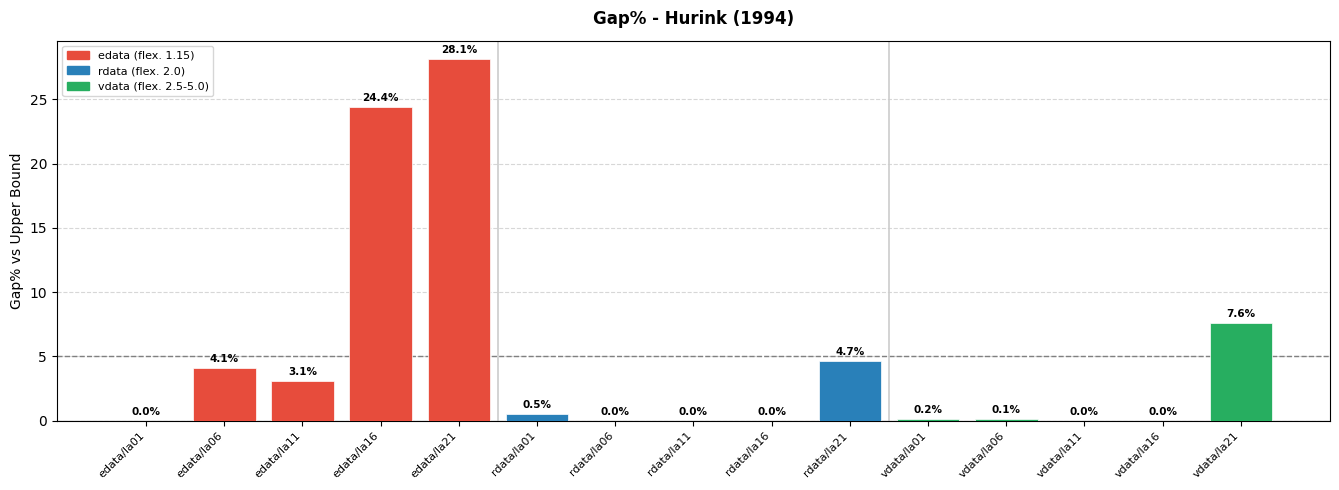

Guardado: graficos/g1_gap_hurink.png


In [8]:
def grafico_gap(filas, titulo, color_func, fname, separadores=None, leyenda=None):
    fig, ax = plt.subplots(figsize=(max(8, len(filas)*0.9), 5))
    etiquetas = [f['instancia'] for f in filas]
    gaps = [f['gap_mejor_pct'] for f in filas]
    x = np.arange(len(filas))
    bars = ax.bar(x, gaps, color=[color_func(f) for f in filas],
                  edgecolor='white', linewidth=0.5, zorder=3)
    for bar, g in zip(bars, gaps):
        off = 0.3 if g >= 0 else -0.3
        va = 'bottom' if g >= 0 else 'top'
        ax.text(bar.get_x()+bar.get_width()/2, g+off, '%.1f%%' % g,
                ha='center', va=va, fontsize=7.5, fontweight='bold')
    ax.axhline(5, color='gray', linestyle='--', linewidth=1, zorder=2)
    ax.axhline(0, color='black', linewidth=0.8, zorder=2)
    if separadores:
        for s in separadores:
            ax.axvline(s, color='#cccccc', linewidth=1.2, zorder=2)
    ax.set_xticks(x); ax.set_xticklabels(etiquetas, fontsize=8, rotation=45, ha='right')
    ax.set_ylabel('Gap% vs Upper Bound', fontsize=10)
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=12)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0); ax.set_axisbelow(True)
    if leyenda:
        ax.legend(handles=leyenda, fontsize=8, loc='upper left')
    plt.tight_layout(); plt.savefig('graficos/%s' % fname, dpi=150, bbox_inches='tight'); plt.show()
    print('Guardado: graficos/%s' % fname)

leyenda_h = [mpatches.Patch(color=COL_HURINK[s], label='%s (flex. %s)' % (s, fx))
             for s, fx in [('edata','1.15'),('rdata','2.0'),('vdata','2.5-5.0')]]
grafico_gap(filas_hurink, 'Gap% - Hurink (1994)', color_hurink,
            'g1_gap_hurink.png', separadores=[4.5, 9.5], leyenda=leyenda_h)


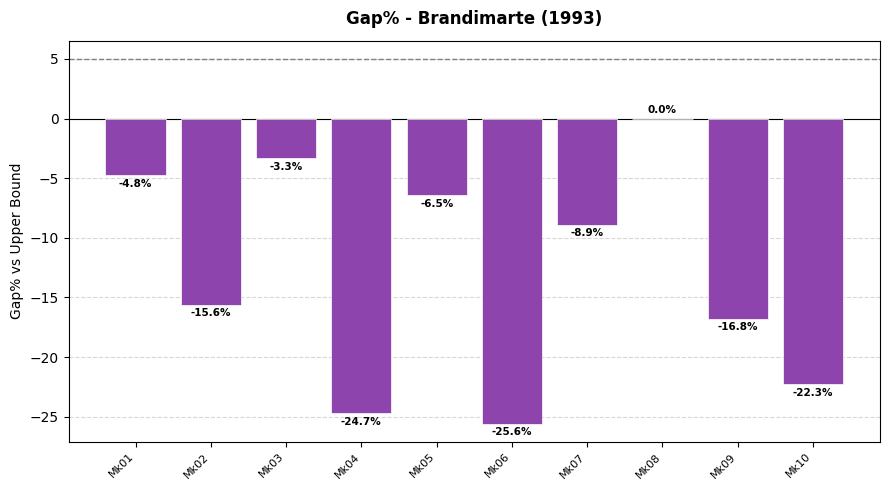

Guardado: graficos/g1_gap_brandimarte.png


In [9]:
grafico_gap(res_por_grupo['Brandimarte'], 'Gap% - Brandimarte (1993)',
            lambda f: COL_BENCH['Brandimarte'], 'g1_gap_brandimarte.png')


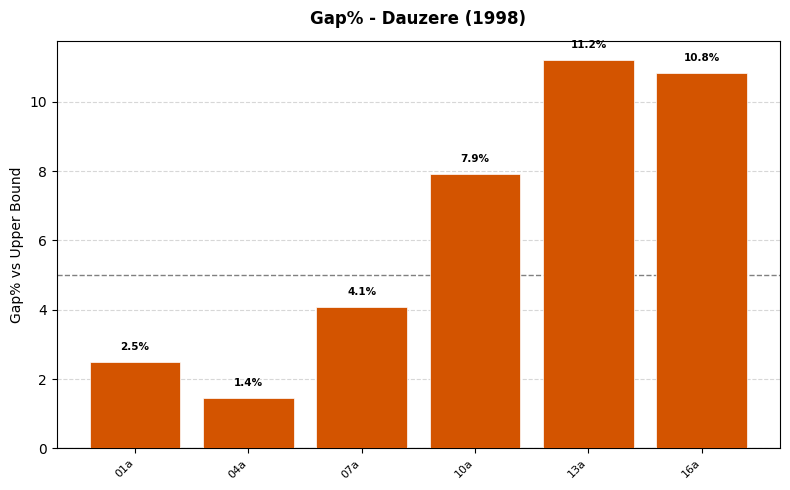

Guardado: graficos/g1_gap_dauzere.png


In [10]:
grafico_gap(res_por_grupo['Dauzere'], 'Gap% - Dauzere (1998)',
            lambda f: COL_BENCH['Dauzere'], 'g1_gap_dauzere.png')


## 9 - Makespan +/- desviacion estandar por benchmark (3 graficos)

Barra = makespan promedio; linea de error = desviacion estandar; rombo naranja =
upper bound de referencia.

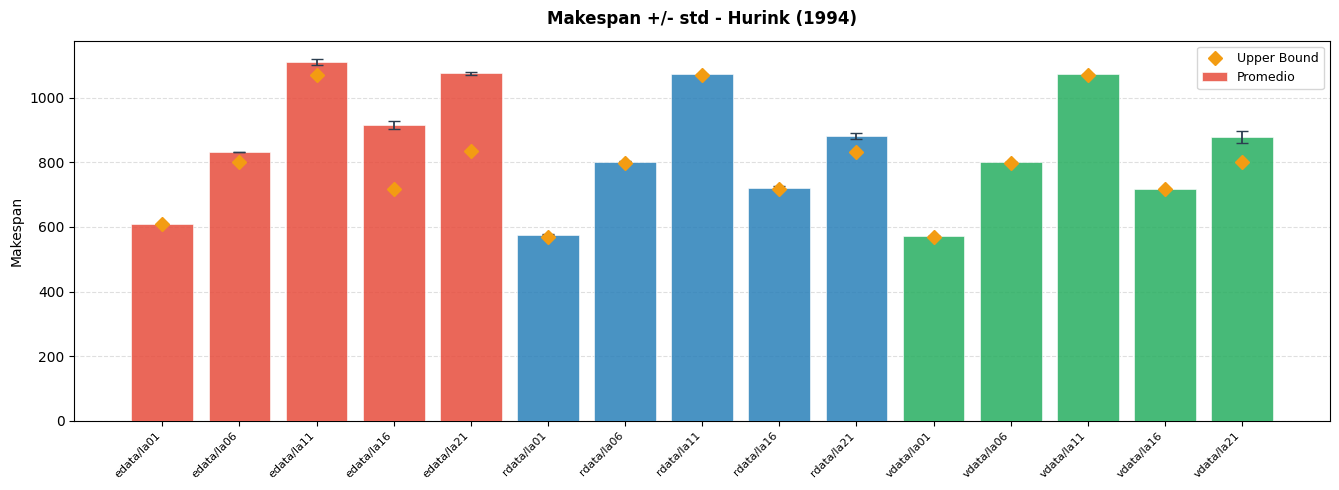

Guardado: graficos/g2_std_hurink.png


In [11]:
def grafico_std(filas, titulo, color_func, fname):
    fig, ax = plt.subplots(figsize=(max(8, len(filas)*0.9), 5))
    etiquetas = [f['instancia'] for f in filas]
    prom = [f['promedio'] for f in filas]
    stds = [f['desv_std'] for f in filas]
    ubs  = [f['ub'] for f in filas]
    x = np.arange(len(filas))
    ax.bar(x, prom, color=[color_func(f) for f in filas], alpha=0.85,
           edgecolor='white', linewidth=0.5, zorder=3, label='Promedio')
    ax.errorbar(x, prom, yerr=stds, fmt='none', color='#2c3e50', capsize=4,
                linewidth=1.3, zorder=4)
    ax.plot(x, ubs, 'D', color='#f39c12', markersize=7, zorder=5, label='Upper Bound')
    ax.set_xticks(x); ax.set_xticklabels(etiquetas, fontsize=8, rotation=45, ha='right')
    ax.set_ylabel('Makespan', fontsize=10)
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=12)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0); ax.set_axisbelow(True)
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.savefig('graficos/%s' % fname, dpi=150, bbox_inches='tight'); plt.show()
    print('Guardado: graficos/%s' % fname)

grafico_std(filas_hurink, 'Makespan +/- std - Hurink (1994)', color_hurink, 'g2_std_hurink.png')


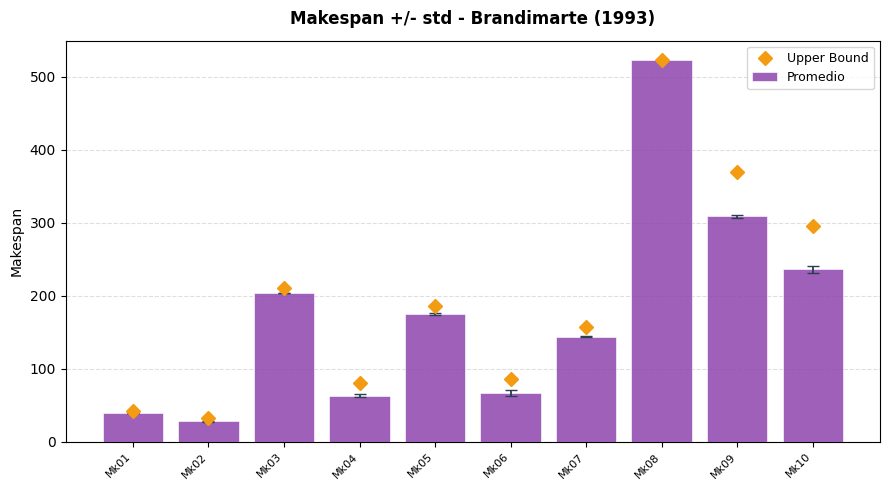

Guardado: graficos/g2_std_brandimarte.png


In [12]:
grafico_std(res_por_grupo['Brandimarte'], 'Makespan +/- std - Brandimarte (1993)',
            lambda f: COL_BENCH['Brandimarte'], 'g2_std_brandimarte.png')


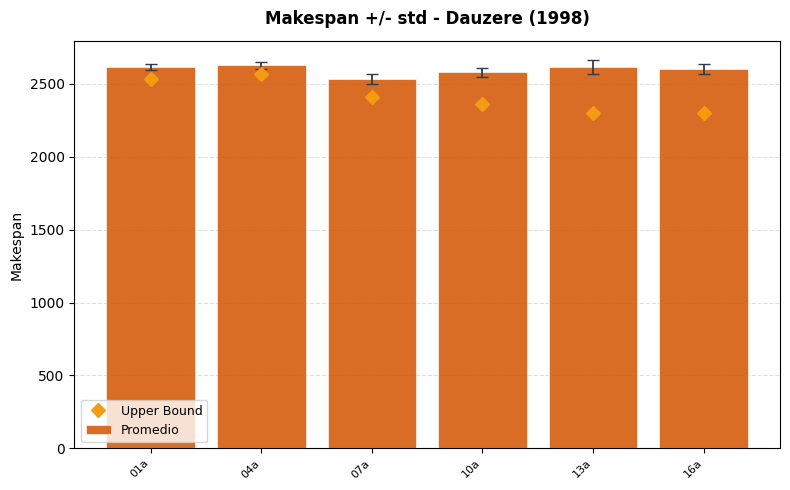

Guardado: graficos/g2_std_dauzere.png


In [13]:
grafico_std(res_por_grupo['Dauzere'], 'Makespan +/- std - Dauzere (1998)',
            lambda f: COL_BENCH['Dauzere'], 'g2_std_dauzere.png')


## 10 - Convergencia por benchmark / flexibilidad (5 graficos)

Curvas reales del mejor makespan por generacion (una por repeticion). La linea
naranja punteada es el upper bound.

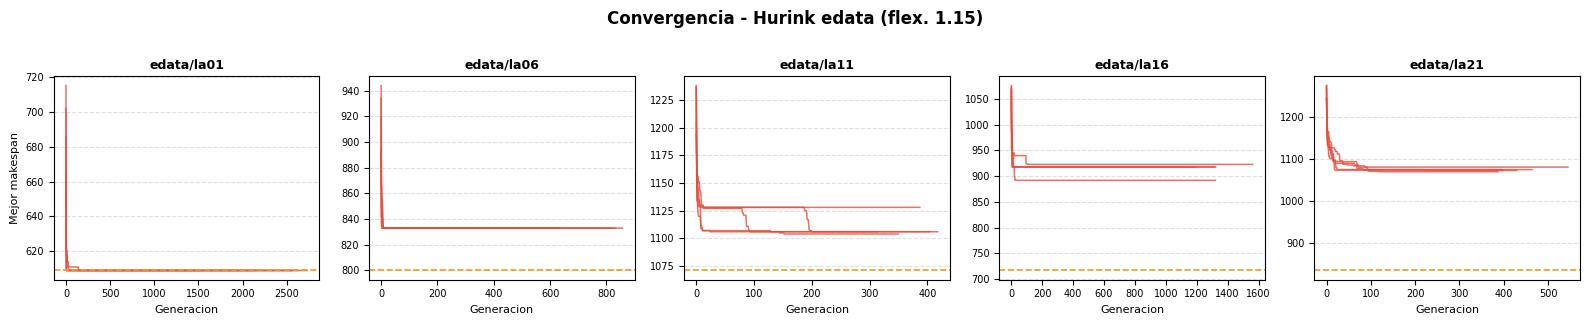

Guardado: graficos/g3_conv_hurink_edata.png


In [14]:
def grafico_convergencia(grupo, titulo, color, fname, ncols=5):
    items = conv[grupo]
    n = len(items)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.2, nrows*3.2), squeeze=False)
    for idx in range(nrows * ncols):
        ax = axes[idx // ncols][idx % ncols]
        if idx >= n:
            ax.axis('off'); continue
        etiqueta, ub, historiales = items[idx]
        for h in historiales:
            ax.plot(range(len(h)), h, linewidth=1.1, alpha=0.8, color=color)
        ax.axhline(ub, color='#f39c12', linestyle='--', linewidth=1.2)
        ax.set_title(etiqueta, fontsize=9, fontweight='bold')
        ax.set_xlabel('Generacion', fontsize=8)
        if idx % ncols == 0:
            ax.set_ylabel('Mejor makespan', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.yaxis.grid(True, linestyle='--', alpha=0.4); ax.set_axisbelow(True)
    fig.suptitle(titulo, fontsize=12, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.savefig('graficos/%s' % fname, dpi=150, bbox_inches='tight'); plt.show()
    print('Guardado: graficos/%s' % fname)

grafico_convergencia('Hurink_edata', 'Convergencia - Hurink edata (flex. 1.15)',
                     COL_HURINK['edata'], 'g3_conv_hurink_edata.png', ncols=5)


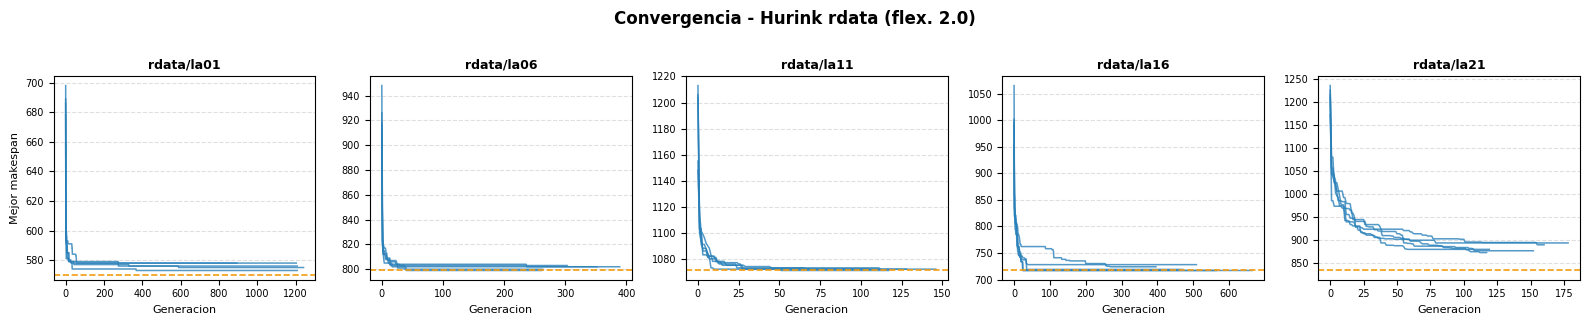

Guardado: graficos/g3_conv_hurink_rdata.png


In [15]:
grafico_convergencia('Hurink_rdata', 'Convergencia - Hurink rdata (flex. 2.0)',
                     COL_HURINK['rdata'], 'g3_conv_hurink_rdata.png', ncols=5)


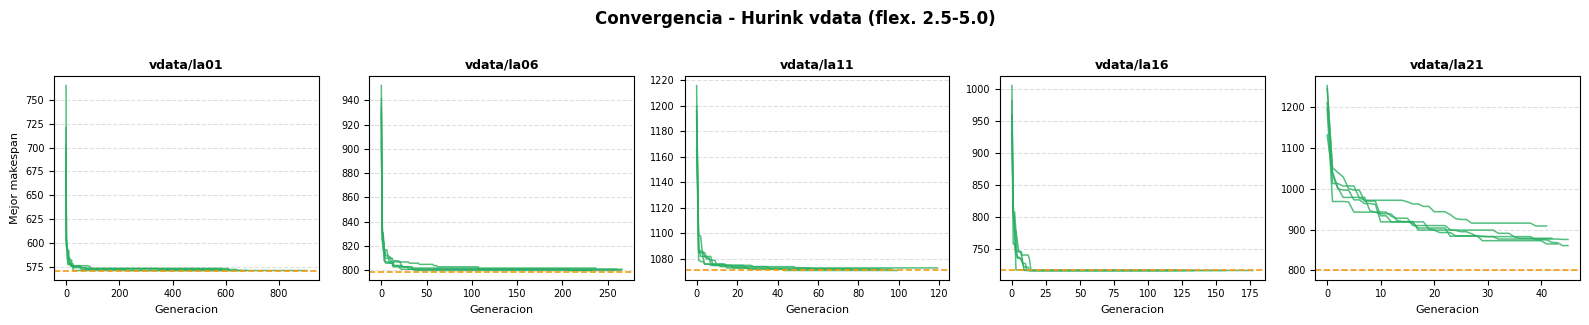

Guardado: graficos/g3_conv_hurink_vdata.png


In [16]:
grafico_convergencia('Hurink_vdata', 'Convergencia - Hurink vdata (flex. 2.5-5.0)',
                     COL_HURINK['vdata'], 'g3_conv_hurink_vdata.png', ncols=5)


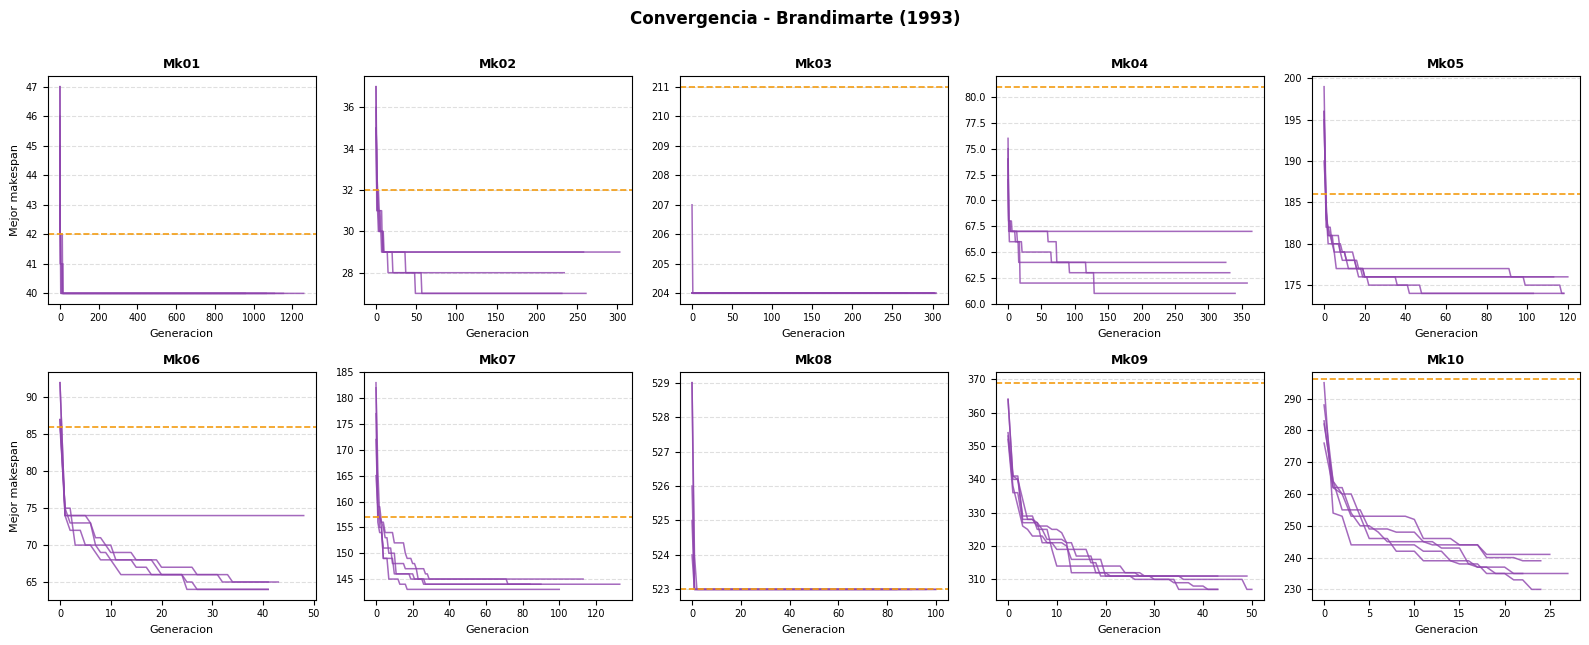

Guardado: graficos/g3_conv_brandimarte.png


In [17]:
grafico_convergencia('Brandimarte', 'Convergencia - Brandimarte (1993)',
                     COL_BENCH['Brandimarte'], 'g3_conv_brandimarte.png', ncols=5)


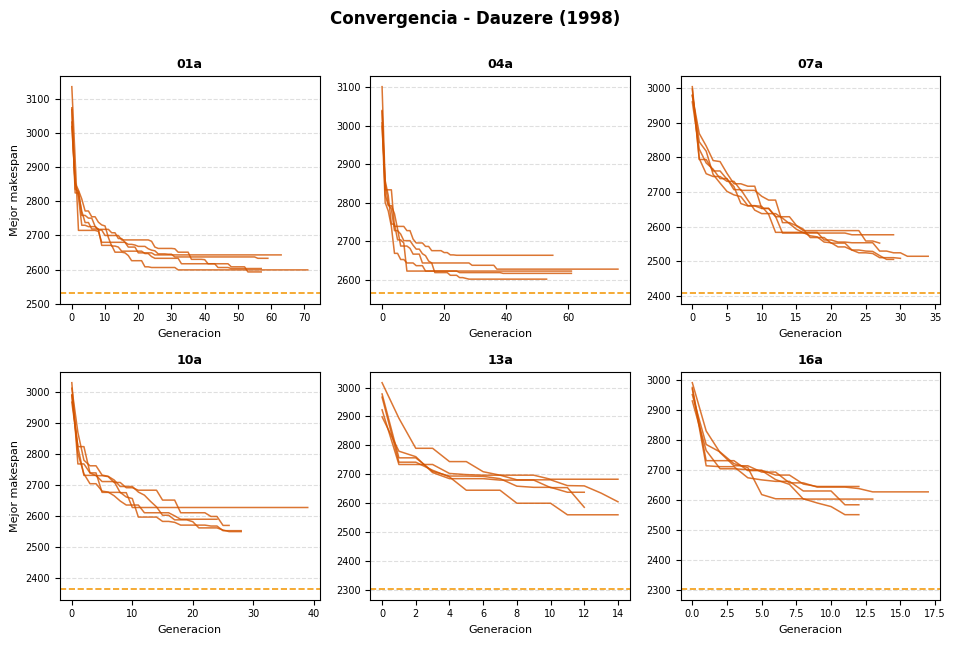

Guardado: graficos/g3_conv_dauzere.png


In [18]:
grafico_convergencia('Dauzere', 'Convergencia - Dauzere (1998)',
                     COL_BENCH['Dauzere'], 'g3_conv_dauzere.png', ncols=3)


## 11 - Descargar resultados y graficos

Empaqueta `resultados/` y `graficos/` en un zip, lo copia tambien a tu carpeta de
Drive y lo descarga.

In [ ]:
import zipfile, shutil
from google.colab import files

with zipfile.ZipFile('entrega_fjsp.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    for carpeta in ['resultados', 'graficos']:
        for raiz, _, archivos in os.walk(carpeta):
            for a in archivos:
                z.write(os.path.join(raiz, a))

# Copia resultados y graficos a la carpeta del proyecto en Drive.
try:
    for carpeta in ['resultados', 'graficos']:
        destino = os.path.join(DRIVE_PROYECTO, carpeta)
        os.makedirs(destino, exist_ok=True)
        for a in os.listdir(carpeta):
            shutil.copy(os.path.join(carpeta, a), os.path.join(destino, a))
    print('Copiado a Drive:', DRIVE_PROYECTO)
except Exception as e:
    print('No se pudo copiar a Drive:', e)

print('Contenido del zip:')
with zipfile.ZipFile('entrega_fjsp.zip') as z:
    for nombre in sorted(z.namelist()):
        print('  ', nombre)

files.download('entrega_fjsp.zip')


Copiado a Drive: /content/drive/My Drive/fjsp_memetico
Contenido del zip:
   graficos/g1_gap_brandimarte.png
   graficos/g1_gap_dauzere.png
   graficos/g1_gap_hurink.png
   graficos/g2_std_brandimarte.png
   graficos/g2_std_dauzere.png
   graficos/g2_std_hurink.png
   graficos/g3_conv_brandimarte.png
   graficos/g3_conv_dauzere.png
   graficos/g3_conv_hurink_edata.png
   graficos/g3_conv_hurink_rdata.png
   graficos/g3_conv_hurink_vdata.png
   resultados/configuracion.txt
   resultados/resultados.xlsx
   resultados/resultados_reporte.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>